# Candidate events, case I and II

This R notebook generates list of candidate events - annotated poison exons with a downstream PAS.

Short workflow:
  - load annotation, identify cassette exons, among them identify poison exons
  - load PAS set from polyASite2.0 and PAS set identified earlier from GTEx and TCGA data. Merge these two sets and annotated PAS (TE).
  - compare frequency of PAS after poison exons and other cassette exons (Figure 1)
  - generate final list poison exons containing a PAS (after the stop codon) or followed by a PAS
  - for the selected list of events generate tables with genomic coordinates of all 4 splice sites, corresponding junctions and constitutive exons surrounding the poison exon.

In [ ]:
library(dplyr)
library(tidyr)
library(stringr)
library(rtracklayer)
library(data.table)

library(purrr)
library(ggplot2)
library(RColorBrewer)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:parallel’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, g

In [4]:
ref_chr <- paste0("chr",c(1:22,"Y","X"))
#data_dir="/media/mashlosenok/Seagate Expansion Drive/arcuda/"
data_dir="../"

## from TxDb

In [5]:
library(GenomicFeatures)
library(AnnotationFilter)

Loading required package: AnnotationDbi

Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.



Attaching package: ‘AnnotationDbi’


The following object is masked from ‘package:dplyr’:

    select




In [6]:
chess_txdb <- loadDb(paste0(data_dir,"references/chess3.1.3.GRCh38.txdb.sqlite"))

In [7]:
prot_cod <- read.table(paste0(data_dir,"references/chess3.1.3.GRCh38.prot_cod_trid.txt"),stringsAsFactors = F)[,1]
length(prot_cod)

[1] 105328

In [81]:
columns(x = chess_txdb)
keytypes(chess_txdb)

[1] "CDSCHROM"   "CDSEND"     "CDSID"      "CDSNAME"    "CDSPHASE"  
 [6] "CDSSTART"   "CDSSTRAND"  "EXONCHROM"  "EXONEND"    "EXONID"    
[11] "EXONNAME"   "EXONRANK"   "EXONSTART"  "EXONSTRAND" "GENEID"    
[16] "TXCHROM"    "TXEND"      "TXID"       "TXNAME"     "TXSTART"   
[21] "TXSTRAND"   "TXTYPE"

[1] "CDSID"    "CDSNAME"  "EXONID"   "EXONNAME" "GENEID"   "TXID"     "TXNAME"

In [12]:
ex <- select(chess_txdb, keys=prot_cod, keytype="TXNAME",
       columns=c('EXONCHROM','EXONSTART','EXONEND','EXONSTRAND','TXNAME','GENEID'))#'EXONRANK',
colnames(ex)  <- c("transcript_id","seqid","strand","start","end","gene_id")#,,"ex_rank"

ex <- ex[ex$seqid %in% ref_chr,]
dim(ex)

ex <- arrange(ex,transcript_id,start) %>% 
mutate(ss4=ifelse(transcript_id==c(transcript_id[-1],"-"),c(start[-1],"-"),"-"),
       ss1=ifelse(transcript_id==c("-",transcript_id[-length(transcript_id)]),c("-",end[-length(end)]),"-"))
dim(ex)

'select()' returned 1:many mapping between keys and columns



[1] 1197828       6

[1] 1197828       8

merge ovrlapping genes

In [13]:
gene_gr <- genes(chess_txdb, columns="gene_id", filter=list(tx_name=c(prot_cod)))

In [14]:
mgenes_gr <- reduce(gene_gr,with.revmap=T)
mgenes_gr$gene_id <- extractList(mcols(gene_gr)$gene_id,mgenes_gr$revmap)

mgenes_id <- unlist(
    lapply(seq_along(mgenes_gr$revmap),function(i) rep(i,length(mgenes_gr$revmap[[i]]))))
names(mgenes_id) <- unlist(mgenes_gr$gene_id)
ex$mgene <- paste0("g",mgenes_id[ex$gene_id])

rm(gene_gr,mgenes_gr)

In [8]:
#load(file="ex.cassette_ex.ATEPE-fromjunc.RData")#ex

### cassette

In [9]:
pure_cas <- ex %>%   
dplyr::rename(ss2=start,ss3=end) %>% 
mutate(ex=paste(seqid,ss2,ss3,strand,sep="_"),
       I1=paste(ss1,ss2,sep="_"),I2=paste(ss3,ss4,sep="_"),E=paste(ss1,ss4,sep="_"),.keep="unused") %>%    
dplyr::select(-c(gene_id,transcript_id)) %>%  
unique %>%   
group_by(mgene) %>% 
mutate(cas1=apply(outer(E,I1,FUN="=="),1,any),
       cas2=apply(outer(E,I2,FUN="=="),1,any), 
       other1=apply(outer(I1,I1,FUN="=="),1,sum)-1,
       other2=apply(outer(I2,I2,FUN="=="),1,sum)-1)     

In [10]:
cas <- pure_cas %>% 
filter(cas1 & cas2) %>% 
dplyr::select(-starts_with(c("other","cas"))) %>% ungroup

In [20]:
length(unique(cas$ex))
dim(cas)

[1] 25158

[1] 29011     5

Cassette ex list files for background distributions

In [ ]:
#write.table(cas,file = "/gss/mvlasenok/references/chess.v313.cassette_ex_R.tsv", 
#quote = F,row.names = F,col.names=F, sep="\t")
cas %>% 
select(-mgene) %>% 
pivot_longer(-ex) %>% unique %>% 
mutate(chr=str_split_fixed(ex,pat="_",n=4)[,1],strand=str_split_fixed(ex,pat="_",n=4)[,4],
       value=paste(chr,value,strand,sep="_")) %>%   
arrange(ex) %>% 
select(-chr,-strand) %>% head
#write.table(.,file = "/gss/mvlasenok/references/chess.v313.cassette_ex_junc.tsv", 
#quote = F, row.names = F,col.names=F, sep="\t")

cas %>% select(ex) %>% unique %>% 
mutate(#
ss2=str_split_fixed(ex,pat="_",n=4)[,2],ss3=str_split_fixed(ex,pat="_",n=4)[,3]) %>% 
pivot_longer(starts_with("ss"),names_to = "ss",values_to="pos") %>% 
mutate(pos=paste(str_split_fixed(ex,pat="_",n=4)[,1],pos,strand=str_split_fixed(ex,pat="_",n=4)[,4],sep="_")) %>%   
arrange(pos) %>% head
#write.table(.,file = "/gss/mvlasenok/references/chess.v313.cassette_ex_exonSS.tsv", 
#quote = F, row.names = F,col.names=F, sep="\t")  

pure cassette

In [272]:
pure_cas %>% 
filter(cas1 & cas2) %>% 
filter(other1==0 & other2==0) %>% 
select(-starts_with(c("other","cas"))) %>% ungroup  %>%  
pull(ex) %>% unique %>% length
#write.table(.,file = "/gss/mvlasenok/references/gencode.v44.cassette_pure_R.n13291.tsv",
 #           quote = F,row.names = F,col.names=F, sep="\t")

[1] 11776

pure cassette that are allowed to share junction with ATE

In [11]:
pure_cas_nonterminal0 <- ex %>%   
dplyr::rename(ss2=start,ss3=end) %>% 
mutate(ex=paste(seqid,ss2,ss3,strand,sep="_"),
       I1=paste(ss1,ss2,sep="_"),I2=paste(ss3,ss4,sep="_"),E=paste(ss1,ss4,sep="_")) %>%  
filter(!(ss1=="-") & !(ss4=="-")) %>% dplyr::select(-starts_with("ss"),-seqid) %>% 
dplyr::select(-c(gene_id,transcript_id,strand)) %>%  
unique %>%   
group_by(mgene) %>% 
mutate(other1_nt=apply(outer(I1,I1,FUN="=="),1,sum)-1,
       other2_nt=apply(outer(I2,I2,FUN="=="),1,sum)-1) %>% 
left_join(cas,.)  

pure_cas_nonterminal <- pure_cas_nonterminal0 %>% 
filter(other1_nt==0 & other2_nt==0) %>% 
dplyr::select(-starts_with("other")) %>% ungroup    

Joining with `by = join_by(mgene, ex, I1, I2, E)`


### poison exons

In [ ]:
pr_cod_tr <- subset(ann,
                type=="transcript" & gene_type=="protein_coding" & !grepl(tag,pat="NF") & seqid %in% ref_chr,
                transcript_id,drop=T)

[1] 99137

In [277]:
stop_gr <- subset(ann,type=="CDS" & transcript_id %in% pr_cod_tr,
        c("seqid","start","end","strand","transcript_id","source")) %>% 
    group_by(transcript_id) %>% 
    summarize(seqid=seqid[1],strand=strand[1],
              start=min(start),end=max(end)) %>% 
    mutate(stop_cod=ifelse(strand=="+",end,start)) %>% 
    with(.,GRanges(seqnames = seqid,strand=strand,
                   ranges = IRanges(start=stop_cod,width=1),transcript_id_stop=transcript_id))

In [278]:
cas_gr <- ex %>% 
mutate(ex=paste(seqid,start,end,strand,sep="_"),
       E=paste(ss1,ss4,sep="_")) %>% 
select(ex,seqid,start,end,strand,transcript_id,E) %>% 
left_join(pure_cas_nonterminal,.,by=c("ex"="ex","E"="E")) %>% 
with(.,GRanges(seqnames = seqid, strand=strand,
               ranges = IRanges(start=start,end=end),ex=ex,E=E,I1=I1,I2=I2,transcript_id=transcript_id))

In [280]:
poison_ex <- with(mergeByOverlaps(cas_gr, stop_gr), cbind(
    as.data.frame(cas_gr)[c("ex","transcript_id","E","I1","I2")], 
    as.data.frame(stop_gr)[c("start","transcript_id_stop")])) %>% 
filter(transcript_id_stop==transcript_id) %>% 
select(-"transcript_id_stop") %>% #unique %>% 
dplyr::rename(stop_cod=start) 

50 bp rule:

In [282]:
poison_ex <- poison_ex %>% 
    mutate(PE_end=as.numeric(ifelse(grepl(ex,pat="+",fix=T),
                         str_split_fixed(ex,pat="_",n=4)[,3],str_split_fixed(ex,pat="_",n=4)[,2])),
            gr_50bp = abs(stop_cod-PE_end)>50) %>% 
    select(-PE_end) 

In [66]:
n_distinct(poison_ex$ex)
n_distinct(poison_ex$ex[poison_ex$gr_50bp])

[1] 2097    7

[1] 1388

[1] 813

In [11]:
write.table(poison_ex, file = "/gss/mvlasenok/references/chess.v313.poison_ex_50bpcolumn.n1388.tsv",
           quote = F,row.names = F,col.names=T, sep="\t")

### ATE

In [4]:
TE_gr <- subset(ann,type=="transcript" & transcript_id %in% pr_cod_tr,
        c("seqid","start","end","strand","transcript_id",'max_TPM','sample_count')) %>% 
    with(.,GRanges(seqnames = seqid,strand=strand,
                   ranges = IRanges(start=ifelse(strand=="+",end,start),width=1),
                   transcript_id_te=transcript_id,max_TPM=max_TPM,sample_count=sample_count))

In [286]:
pe_stop_Eja_gr <- poison_ex %>% 
    mutate(Ej_a=as.numeric(ifelse(grepl(x=ex,pat="+",fixed=T),
                       str_split_fixed(E,pat="_",n=4)[,2],str_split_fixed(E,pat="_",n=4)[,1])))  %>% 
    with(.,GRanges(seqnames = str_split_fixed(ex,pat="_",n=4)[,1],
                   strand = str_split_fixed(ex,pat="_",n=4)[,4],
                   range=IRanges(start=ifelse(grepl(x=ex,pat="+",fixed=T),stop_cod,Ej_a),width=abs(stop_cod-Ej_a)),
                   ex=ex,transcript_id=transcript_id,E=E,stop_cod=stop_cod,gr_50bp=gr_50bp))

### Compare PAS after cassette and poison

poison Granges

In [289]:
pe_exstart_Eja_gr <- poison_ex %>% 
mutate(Ej_a=as.numeric(ifelse(grepl(x=ex,pat="+",fixed=T),
                   str_split_fixed(E,pat="_",n=4)[,2],str_split_fixed(E,pat="_",n=4)[,1])),
        ex_st=as.numeric(ifelse(grepl(x=ex,pat="+",fixed=T),
                   str_split_fixed(ex,pat="_",n=4)[,2],str_split_fixed(ex,pat="_",n=4)[,2])))  %>% 
with(.,GRanges(seqnames = str_split_fixed(ex,pat="_",n=4)[,1],
               strand = str_split_fixed(ex,pat="_",n=4)[,4],
               range=IRanges(start=ifelse(grepl(x=ex,pat="+",fixed=T),ex_st,Ej_a),width=abs(ex_st-Ej_a)),
               ex=ex,transcript_id=transcript_id,E=E,stop_cod=stop_cod,gr_50bp=gr_50bp))

Pure cassette Granges

In [292]:
cas_exstart_Eja_gr <- pure_cas_nonterminal %>% 
mutate(Ej_a=as.numeric(ifelse(grepl(x=ex,pat="+",fixed=T),
                   str_split_fixed(E,pat="_",n=4)[,2],str_split_fixed(E,pat="_",n=4)[,1])),
        ex_st=as.numeric(ifelse(grepl(x=ex,pat="+",fixed=T),
                   str_split_fixed(ex,pat="_",n=4)[,2],str_split_fixed(ex,pat="_",n=4)[,2])))  %>% 
with(.,GRanges(seqnames = str_split_fixed(ex,pat="_",n=4)[,1],
               strand = str_split_fixed(ex,pat="_",n=4)[,4],
               range=IRanges(start=ifelse(grepl(x=ex,pat="+",fixed=T),ex_st,Ej_a),width=abs(ex_st-Ej_a)),
               ex=ex,E=E))#I1=I1,I2=I2))

In [294]:
mcols(cas_exstart_Eja_gr) <- left_join(data.frame(mcols(cas_exstart_Eja_gr)), 
                                       unique(subset(poison_ex,gr_50bp,c(ex,E,gr_50bp))))
mcols(cas_exstart_Eja_gr) <- data.frame(mcols(cas_exstart_Eja_gr)) %>% 
    mutate(poison=ifelse(is.na(gr_50bp),FALSE,gr_50bp))
mcols(cas_exstart_Eja_gr)$has_TE <- overlapsAny(cas_exstart_Eja_gr,TE_gr)

Joining with `by = join_by(ex, E)`


In [296]:
with(mcols(cas_exstart_Eja_gr),sum(has_TE & poison))
with(mcols(cas_exstart_Eja_gr),chisq.test(has_TE,poison)$p.value)
with(mcols(cas_exstart_Eja_gr),
     (sum(has_TE & poison)/sum(has_TE & !poison))/(sum(!has_TE & poison)/sum(!has_TE & !poison)))

[1] 63

[1] 6.928225e-22

[1] 3.751135

#### add polyAread PAS

In [ ]:
pas_gr <- rtracklayer::import("pasc_gtex_tcga_wpAcounts_tumour_norm.bed",format = "BED",
extraCols=c("signal"="factor","gtex"="integer","tcga"="integer","tum"="integer","norm"="integer"))
mcols(pas_gr)$signal <- mcols(pas_gr)$signal=="signal"

In [ ]:
sum(overlapsAny(cas_exstart_Eja_gr,pas_gr[pas_gr$signal & pas_gr$score>10]))

[1] 3002

#### OR for different read support

#### Atlas PAS OR

In [69]:
atlas_gr <- rtracklayer::import("atlas.clusters.2.0.GRCh38.96.bed", format = "BED", 
    extraCols=c(frac_samples="numeric",nr_prots="numeric",exp="numeric",ann="factor",signal="character")) 
mcols(atlas_gr) <- data.frame(mcols(atlas_gr)) %>% select(-c(signal,ann,nr_prots,exp))
#score = average expression
seqlevelsStyle(atlas_gr) <- "UCSC"

In [70]:
sum(overlapsAny(cas_exstart_Eja_gr,atlas_gr))
summary(atlas_gr$score)
summary(atlas_gr$frac_samples)

[1] 4733

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   0.000    0.003    0.007    1.348    0.033 5548.189 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.03763 0.02000 0.90000 

In [71]:
atlas_df <- map_dfr(c(0.01,0.02,0.05,0.1,0.2,0.5,1,1.75), function(cur_thr) {
    v=overlapsAny(cas_exstart_Eja_gr,atlas_gr[atlas_gr$score>cur_thr]);
    tibble(
      scr_thr = cur_thr,
      cas_ex_wPAS = sum(v),
      chisq_pval = chisq.test(v,cas_exstart_Eja_gr$poison)$p.value,
      OR = with(mcols(cas_exstart_Eja_gr),
          (sum(v & poison)/sum(v & !poison))/(sum(!v & poison)/sum(!v & !poison))),
      SE2=with(mcols(cas_exstart_Eja_gr),
          1/sum(v & poison)+1/sum(v & !poison)+1/sum(!v & poison)+1/sum(!v & !poison)),
    )
  })

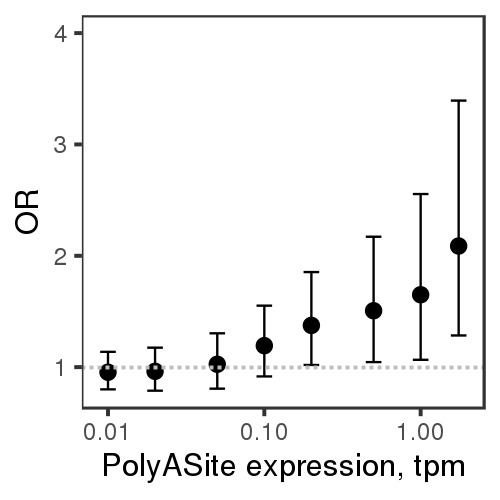

In [75]:
options(repr.plot.width = 2.5, repr.plot.height = 2.5, repr.plot.res = 200)

atlas_df %>% 
mutate(CI_t=exp(log(OR)+1.96*sqrt(SE2)),CI_b=exp(log(OR)-1.96*sqrt(SE2))) %>% 

ggplot(.,aes(x=scr_thr,y=OR))+
geom_point(size=2)+
geom_errorbar(aes(ymin = CI_b, ymax = CI_t), width=.1,lwd=0.3)+
#scale_color_manual(values = c("grey50","black"))+
scale_x_continuous(trans="log10")+
ylim(c(NA,4))+
geom_hline(yintercept = 1,lty=2,color="grey")+
theme_bw()+xlab("PolyASite expression, tpm")+
theme(panel.grid = element_blank(), legend.position="none")

#### PAS OR  with confidence intervals
e^(log(OR) ± 1.96 x sqrt(1/a + 1/b + 1/c + 1/d))

In [52]:
tot_df <- map_dfr(c(TRUE,FALSE), function(cur_sig) {
  map_dfr(c(1,10,25,50,100,250,500,1000), function(cur_thr) {
    v=overlapsAny(cas_exstart_Eja_gr,pas_gr[pas_gr$signal>=cur_sig & pas_gr$pAreads>cur_thr]);
    tibble(
      signal=ifelse(cur_sig,"signal","any"),
      scr_thr = cur_thr,
      cas_ex_wPAS = sum(v),
      chisq_pval = chisq.test(v,cas_exstart_Eja_gr$poison)$p.value,
      OR = with(mcols(cas_exstart_Eja_gr),
          (sum(v & poison)/sum(v & !poison))/(sum(!v & poison)/sum(!v & !poison))),
      SE2=with(mcols(cas_exstart_Eja_gr),
          1/sum(v & poison)+1/sum(v & !poison)+1/sum(!v & poison)+1/sum(!v & !poison))
    )
  })
})

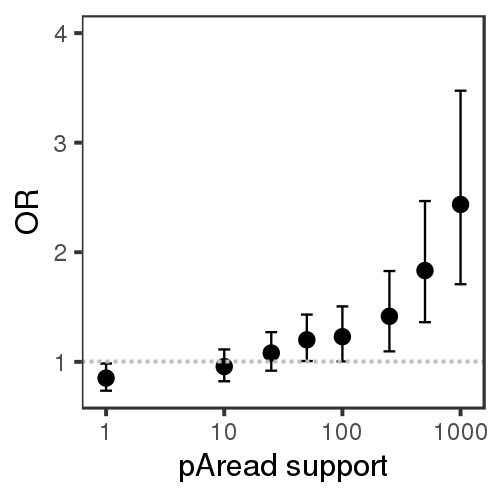

In [67]:
options(repr.plot.width = 2.5, repr.plot.height = 2.5, repr.plot.res = 200)


tot_df %>% 
filter(signal=="any") %>% 
mutate(CI_t=exp(log(OR)+1.96*sqrt(SE2)),CI_b=exp(log(OR)-1.96*sqrt(SE2))) %>% 

ggplot(.,aes(x=scr_thr,y=OR))+geom_point(size=2)+
geom_errorbar(aes(ymin = CI_b, ymax = CI_t), width=.1,lwd=0.3)+
geom_hline(yintercept = 1,lty=2,color="grey")+
#scale_color_manual(values = c("grey60","black"))+scale_fill_manual(values = c("white","black"))+
scale_x_continuous(trans="log10")+
scale_color_manual(values=brewer.pal(4,"Reds")[c(2,3)])+
theme_bw()+xlab("pAread support")+
ylim(c(NA,4))+
theme(panel.grid = element_blank(), legend.position="none")

Signal dependence

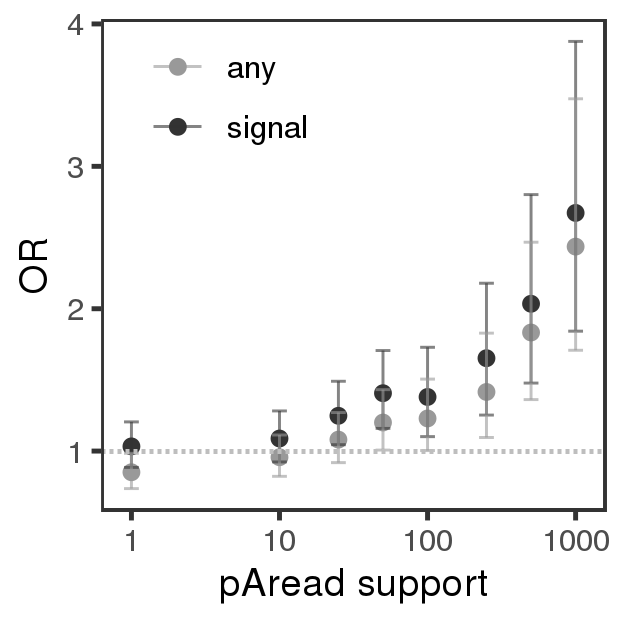

In [59]:
options(repr.plot.width = 2.5, repr.plot.height = 2.5, repr.plot.res = 250)


tot_df %>% 
#filter(signal=="any") %>% 
mutate(CI_t=exp(log(OR)+1.96*sqrt(SE2)),CI_b=exp(log(OR)-1.96*sqrt(SE2))) %>% 

ggplot(.,aes(x=scr_thr,y=OR,color=signal))+geom_point(size=1.5)+
geom_errorbar(aes(ymin = CI_b, ymax = CI_t), width=.1,lwd=0.3,alpha=0.6)+
geom_hline(yintercept = 1,lty=2,color="grey")+
#scale_color_manual(values = c("grey60","black"))+scale_fill_manual(values = c("white","black"))+
scale_x_continuous(trans="log10")+
scale_color_manual(values=c("grey60","grey20"))+
theme_bw()+xlab("pAread support")+labs(color="")+
#ylim(c(NA,4))+
theme(panel.grid = element_blank(),
      legend.position=c(0.25,0.9),legend.background=element_rect(fill="transparent"))

**exclude TE (SuppFig 2B)**

In [45]:
pas_noTE <- pas_gr[!overlapsAny(pas_gr,TE_gr)]

tot_noTE_df <- map_dfr(c(TRUE,FALSE), function(cur_sig) {
  map_dfr(c(1,10,25,50,100,250,500,1000), function(cur_thr) {
    v=overlapsAny(cas_exstart_Eja_gr,pas_noTE[pas_noTE$signal>=cur_sig & pas_noTE$pAreads>cur_thr]);
    tibble(
      signal=ifelse(cur_sig,"+signal","any"),
      scr_thr = cur_thr,
      cas_ex_wPAS = sum(v),
      chisq_pval = chisq.test(v,cas_exstart_Eja_gr$poison)$p.value,
      OR = with(mcols(cas_exstart_Eja_gr),
          (sum(v & poison)/sum(v & !poison))/(sum(!v & poison)/sum(!v & !poison))),
      SE2=with(mcols(cas_exstart_Eja_gr),
          1/sum(v & poison)+1/sum(v & !poison)+1/sum(!v & poison)+1/sum(!v & !poison))
    )
  })
})

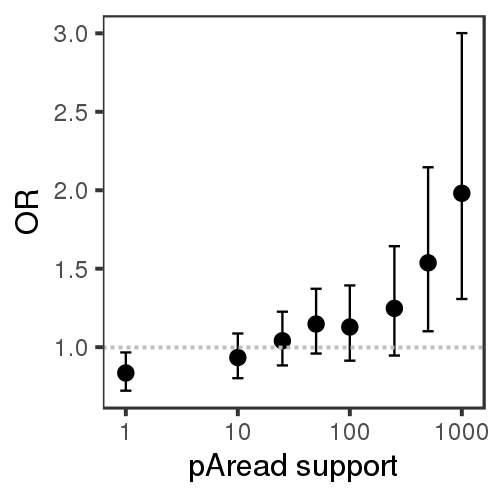

In [64]:
options(repr.plot.width = 2.5, repr.plot.height = 2.5, repr.plot.res = 200)


tot_noTE_df %>% 
filter(signal=="any") %>% 
mutate(CI_t=exp(log(OR)+1.96*sqrt(SE2)),CI_b=exp(log(OR)-1.96*sqrt(SE2))) %>% 

ggplot(.,aes(x=scr_thr,y=OR))+geom_point(size=2)+
geom_errorbar(aes(ymin = CI_b, ymax = CI_t), width=.1,lwd=0.3)+
geom_hline(yintercept = 1,lty=2,color="grey")+
#scale_color_manual(values = c("grey60","black"))+scale_fill_manual(values = c("white","black"))+
scale_x_continuous(trans="log10")+
scale_color_manual(values=brewer.pal(4,"Reds")[c(2,3)])+
theme_bw()+xlab("pAread support")+
#ylim(c(NA,3.5))+
theme(panel.grid = element_blank(), legend.position="none")

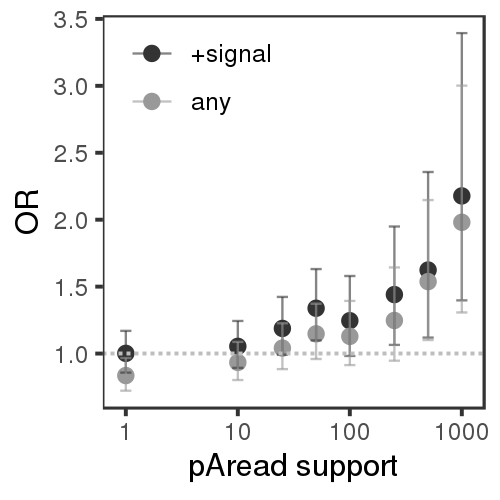

In [47]:
options(repr.plot.width = 2.5, repr.plot.height = 2.5, repr.plot.res = 200)


tot_noTE_df %>% 
#filter(signal=="any") %>% 
mutate(CI_t=exp(log(OR)+1.96*sqrt(SE2)),CI_b=exp(log(OR)-1.96*sqrt(SE2))) %>% 

ggplot(.,aes(x=scr_thr,y=OR,color=signal))+geom_point(size=2)+
geom_errorbar(aes(ymin = CI_b, ymax = CI_t), width=.1,lwd=0.3,alpha=0.6)+
geom_hline(yintercept = 1,lty=2,color="grey")+
#scale_color_manual(values = c("grey60","black"))+scale_fill_manual(values = c("white","black"))+
scale_x_continuous(trans="log10")+
scale_color_manual(values=c("grey20","grey60"))+
theme_bw()+xlab("pAread support")+labs(color="")+
#ylim(c(NA,4))+
theme(panel.grid = element_blank(),
      legend.position=c(0.25,0.9),legend.background=element_rect(fill="transparent"))

#### Joined PAS sets

In [81]:
v=overlapsAny(cas_exstart_Eja_gr,TE_gr);

joined_df <- rbind(
    mutate(subset(tot_df, signal=="any",-signal),PASset='pAreads'),
    mutate(atlas_df, PASset='atlas'),
    tibble(
      scr_thr = 0,
      cas_ex_wPAS = sum(v),
      chisq_pval = chisq.test(v,cas_exstart_Eja_gr$poison)$p.value,
      OR = with(mcols(cas_exstart_Eja_gr),
          (sum(v & poison)/sum(v & !poison))/(sum(!v & poison)/sum(!v & !poison))),
      SE2=with(mcols(cas_exstart_Eja_gr),
          1/sum(v & poison)+1/sum(v & !poison)+1/sum(!v & poison)+1/sum(!v & !poison)),
      PASset="TE"))

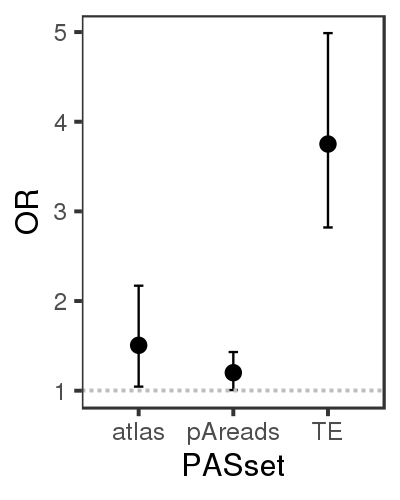

In [86]:
options(repr.plot.width = 2, repr.plot.height = 2.5, repr.plot.res = 200)

joined_df %>% 
filter(PASset=="TE" | (PASset=='pAreads' & scr_thr==50) | (PASset=='atlas' & scr_thr==0.5)) %>% 
mutate(CI_t=exp(log(OR)+1.96*sqrt(SE2)),CI_b=exp(log(OR)-1.96*sqrt(SE2))) %>% 
ggplot(.,aes(x=PASset,y=OR))+geom_point(size=2)+
geom_errorbar(aes(ymin = CI_b, ymax = CI_t), width=.1,lwd=0.3)+
#scale_color_manual(values=brewer.pal(4,"Reds")[c(3,3,4)])+
theme_bw()+
geom_hline(yintercept = 1,lty=2,color="grey")+
theme(panel.grid.major = element_blank(),panel.grid.minor = element_blank(),
     legend.position="none")

### Join PAS sets: annotated TE, GTEX_TCGA PAS, polyASite

In [20]:
TE_gr_red <- data.frame(TE_gr) %>% 
group_by(seqnames,start,end,strand) %>% 
arrange(transcript_id_te) %>% 
summarize(transcript_id_te=transcript_id_te[ifelse(any(!is.na(max_TPM)),which.max(max_TPM),1)], 
        max_TPM=max(max_TPM)) %>% ungroup %>% 
mutate(source="TE") %>% 
makeGRangesFromDataFrame(., keep.extra.columns=TRUE)
#seqnames = seqid,strand=strand,
   # ranges = IRanges(start=ifelse(strand=="+",end,start),width=1),
    #transcript_id_te=transcript_id,max_TPM=max_TPM,sample_count=sample_count))

`summarise()` has grouped output by 'seqnames', 'start', 'end'. You can
override using the `.groups` argument.


change some columns before joining (easier to extract list later):

In [21]:
mcols(atlas_gr) <- mcols(atlas_gr) %>% data.frame %>% select(-frac_samples) %>% 
rename(score="atlas_exp") %>% mutate(source="atlas")
mcols(pas_gr) <- data.frame(mcols(pas_gr)) %>% rename(score="pAreads",tum="tcga_tum",norm="tcga_norm") %>% 
mutate(source="pAread")

In [55]:
allpas_gr0 <- c(pas_gr,atlas_gr,TE_gr_red)

Warning message in .Seqinfo.mergexy(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': GL000008.2, GL000009.2, GL000194.1, GL000195.1, GL000205.2, GL000208.1, GL000213.1, GL000214.1, GL000216.2, GL000218.1, GL000219.1, GL000220.1, GL000221.1, GL000224.1, GL000225.1, KI270330.1, KI270333.1, KI270418.1, KI270435.1, KI270442.1, KI270466.1, KI270467.1, KI270517.1, KI270519.1, KI270582.1, KI270587.1, KI270591.1, KI270706.1, KI270707.1, KI270708.1, KI270709.1, KI270711.1, KI270712.1, KI270713.1, KI270714.1, KI270717.1, KI270719.1, KI270720.1, KI270722.1, KI270723.1, KI270724.1, KI270725.1, KI270726.1, KI270727.1, KI270728.1, KI270729.1, KI270731.1, KI270732.1, KI270733.1, KI270734.1, KI270735.1, KI270736.1, KI270737.1, KI270738.1, KI270742.1, KI270743.1, KI270744.1, KI270746.1, KI270747.1, KI270748.1, KI270749.1, KI270750.1, KI270751.1, KI270752.1, KI270753.1, KI270754.1
  - in 'y': chrM, chr1_GL383518v1_alt, chr1_GL383519v1_alt, chr1_GL383520v2_alt, chr

In [20]:
allpas_gr <- GenomicRanges::reduce(allpas_gr0,with.revmap=T) #maybe add 10 bp distance?

In [21]:
allpas_gr$source <- 
sapply(extractList(mcols(allpas_gr0)$source,allpas_gr$revmap), 
function(x) paste(unique(sort(x)),collapse=","))

transcript id with the highest max_TPM

In [22]:
revmap_val <- sapply(extractList(mcols(allpas_gr0)$max_TPM, allpas_gr$revmap), 
                                function(x) ifelse(any(!is.na(x)),which.max(x),1))
trid_indeces <- unlist(allpas_gr$revmap)[
    cumsum(lengths(allpas_gr$revmap)) - (lengths(allpas_gr$revmap)-revmap_val)]
allpas_gr$transcript_id_te <- allpas_gr0$transcript_id_te[trid_indeces]

#colnames(mcols(allpas_gr)) <- c('revmap','transcript_id_te','source','pAread','atlas_exp','max_TPM')

In [23]:
allpas_gr$pAread <- sapply(extractList(mcols(allpas_gr0)$pAreads,allpas_gr$revmap),sum, na.rm = T)
allpas_gr$signal <- sapply(extractList(mcols(allpas_gr0)$signal,allpas_gr$revmap),any)
allpas_gr$atlas_exp <- sapply(extractList(mcols(allpas_gr0)$atlas_exp,allpas_gr$revmap),sum, na.rm = T)

#options(warn=-1)
#allpas_gr$max_TPM <- sapply(extractList(mcols(allpas_gr0)$max_TPM,allpas_gr$revmap),max,na.rm = TRUE)

In [27]:
allpas_gr <- allpas_gr[seqnames(allpas_gr) %in% ref_chr]

In [28]:
summary(width(allpas_gr))
sum(width(allpas_gr)>100)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   1.000   5.715   5.000 314.000 

[1] 642

file with merged PAS

In [29]:
allpas_gr %>% data.frame %>% select(-width,-revmap) %>% rename(seqnames="chr") %>% 
    mutate(name=".",score=as.integer(pAread),.after=end)  
    #write.table(.,file = "allPAS_w_chess.bed", quote = F,row.names = F,col.names=T, sep="\t")

In [3]:
rm(ate_ex0,pas_0,p2,lst,v2,r2,mgenes_id,trid_indeces,revmap_val)

#### ATE-PE based on the merged PAS

Exons with PAS list: (threshols: atlas any, polyAread>10)

In [4]:
allpas_gr_filt <- allpas_gr[
    with(mcols(allpas_gr),grepl(source,pat="TE") | grepl(source,pat="atlas") | pAread>10) & width(allpas_gr)<=100 ]

In [10]:
ATE_PE <- 
    with(mergeByOverlaps(pe_stop_Eja_gr, allpas_gr_filt), cbind(
        as.data.frame(pe_stop_Eja_gr)[c("ex","transcript_id","E","stop_cod","gr_50bp")], 
        as.data.frame(allpas_gr_filt)[c("start","transcript_id_te","source","pAread","atlas_exp","max_TPM")])) %>% 
    dplyr::rename(TE=start,max_TPM.ate=max_TPM)    
#n=676 uniq exons, 375 with 50-bp rule, 71 for TE

### Final outputs. Add ref data, create we and surrownding exons files

Save cassette-ATE list for backgroud distribution

In [17]:
mcols(cas_exstart_Eja_gr) %>% as.data.frame %>% 
write.table(.,file = "all_cod_exons_I1I2/all_cassette.poison_indicator.annTE.tsv", 
            quote = F,row.names = F,col.names=T, sep="\t")

In [17]:
ATE_cas <- with(mergeByOverlaps(cas_exstart_Eja_gr, allpas_gr_filt), cbind(
    as.data.frame(cas_exstart_Eja_gr)[c("ex","E","gr_50bp","poison")], 
    as.data.frame(allpas_gr_filt)[c("start","transcript_id_te","source","pAread","atlas_exp","max_TPM")])) %>%   
dplyr::rename(TE=start,max_TPM.ate=max_TPM)    
#write.table(.,file = "all_cod_exons_I1I2/all_cassette.poison_indicator.allPAS.tsv", 
 #           quote = F,row.names = F,col.names=T, sep="\t")

#### CHESS: add other ref data 

In [11]:
ATE_PE <- ATE_PE %>% 
    left_join(.,
              subset(ann,type=="transcript" & transcript_id %in% pr_cod_tr,
                     c("transcript_id","gene_name","db_xref","max_TPM","sample_count"))) %>% 
    select(-max_TPM.ate) %>% 
    left_join(.,subset(ann,type=="transcript" & transcript_id %in% pr_cod_tr,
                       c("transcript_id","db_xref","sample_count","max_TPM")),
              by=join_by(transcript_id_te==transcript_id), suffix = c(".nmd", ".ate"))  

Joining with `by = join_by(transcript_id)`


**File with final ATE-PE list**

In [14]:
left_join(ATE_PE,select(cas,-mgene)) %>%  
    mutate(across(c(I1,I2,E),
              ~paste(str_split_fixed(ex,pat="_",n=4)[,1],.x,str_split_fixed(ex,pat="_",n=4)[,4],sep="_"))) %>%     
#write.table(.,file = "ATE_PE_chess_allpas_n675.tab", quote = F,row.names = F,col.names=T, sep="\t")

Joining with `by = join_by(ex, E)`


#### Files with surrownding exons coords for all cassette for background. 
Considering that the exon can be shorter than 150bp: add transcript id, get next exon length

In [5]:
sur_ex <- subset(ann,type=="exon" & transcript_id %in% pr_cod_tr,
            c("seqid","start","end","strand","transcript_id","gene_id")) %>% 
arrange(transcript_id,start)  %>% 
mutate(e1=ifelse(transcript_id==c("-",transcript_id[-length(transcript_id)]),
                 paste(c("-",start[-length(start)]),c("-",end[-length(end)]),sep="_"),"-"),
       e2=ifelse(transcript_id==c(transcript_id[-1],"-"),paste(start[-1],end[-1],sep="_"),"-"))

sur_ex <- sur_ex %>%
mutate(E=paste(str_split_fixed(e1,n=2,pat="_")[,2],str_split_fixed(e2,n=2,pat="_")[,1],sep="_"),
       ex=paste(seqid,start,end,strand,sep="_")) %>% select(ex,E,e1,e2) %>% unique

In [22]:
sur_ex <- 
left_join(pure_cas_nonterminal0,sur_ex) %>% 
select(-mgene) %>% 
mutate(across(c(e1,e2), .names="{.col}_l", 
              ~ as.numeric(str_split_fixed(.x,n=2,pat="_")[,2])-as.numeric(str_split_fixed(.x,n=2,pat="_")[,1])),
    e1_w=ifelse(e1_l < 150, e1,
       paste(as.numeric(str_split_fixed(e1,n=2,pat="_")[,2])-150,str_split_fixed(e1,n=2,pat="_")[,2],sep="_")),
    e2_w=ifelse(e2_l < 150, e2,
       paste(str_split_fixed(e2,n=2,pat="_")[,1],as.numeric(str_split_fixed(e2,n=2,pat="_")[,1])+150,sep="_"))) %>% 
mutate(pure_nt= other1_nt==0 & other2_nt==0,.keep="unused")

Joining with `by = join_by(ex, E)`


tsv cassette exons data:

In [24]:
sur_ex %>% 
mutate(across(c(I1,I2,E,e1,e2,e1_w,e2_w),
              ~paste(str_split_fixed(ex,pat="_",n=4)[,1],.x,str_split_fixed(ex,pat="_",n=4)[,4],sep="_"))) %>%       
#write.table(.,file = "../references/chess.v313.cassette_ex_junc_surexon.tsv", 
 #           quote = F,row.names = F,col.names=T, sep="\t")

Bed for coverage (all cassette)

In [41]:
sur_ex %>% 
select(ex,e1_w,e2_w) %>% 
unique %>% 
pivot_longer(-c(ex),values_to="sur_ex") %>% 
mutate(chr=str_split_fixed(ex,pat="_",n=4)[,1],
       start=as.integer(str_split_fixed(sur_ex,pat="_",n=4)[,1]),
       end=as.integer(str_split_fixed(sur_ex,pat="_",n=4)[,2]),.before=everything()) %>% 
mutate(score="0",strand=str_split_fixed(ex,pat="_",n=4)[,4],
       ex=paste(ex,gsub(x=name,pat="_w",rep=""),sep="|"),.keep="unused") %>% 
select(-sur_ex) %>% unique %>% 
arrange(chr,start,end) %>% head
#write.table(.,file = "chess.v313.surexon_windows.bed", quote = F,row.names = F,col.names=F, sep="\t")

sur_ex %>%
select(ex) %>% unique %>% 
mutate(chr=str_split_fixed(ex,pat="_",n=4)[,1],
       start=(str_split_fixed(ex,pat="_",n=4)[,2]),
       end=(str_split_fixed(ex,pat="_",n=4)[,3]),.before=everything()) %>% 
mutate(score="0",strand=str_split_fixed(ex,pat="_",n=4)[,4]) %>% 
       #ex=paste(ex,gsub(x=name,pat="_w",rep=""),sep="|"),.keep="unused") %>% 
arrange(chr,start,end) %>% 
#write.table(.,file = "chess.v313.cas_exon_for_cov.bed", quote = F,row.names = F,col.names=F, sep="\t")

chr,start,end,ex,score,strand
<chr>,<int>,<int>,<chr>,<chr>,<chr>
chr1,954004,954082,chr1_954464_954523_-|e1,0,-
chr1,955923,956013,chr1_954464_954523_-|e2,0,-
chr1,972861,973010,chr1_973186_973326_+|e1,0,+
chr1,973500,973640,chr1_973186_973326_+|e2,0,+
chr1,999526,999613,chr1_999692_999787_-|e1,0,-
chr1,999866,1000016,chr1_999692_999787_-|e2,0,-
